In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import griddata

In [2]:
def collect_all_results(root_path):
    all_rows = []
    for csv_file in Path(root_path).rglob('losses_*.csv'):
        # Estraggo l'exp_str dal nome del file, se ti serve
        exp_str = csv_file.stem.replace("losses_", "")
        
        # Carico il CSV in un DF
        df = pd.read_csv(csv_file)
        # Aggiungo colonna 'exp_str' per distinguere l'esperimento
        df['exp_str'] = exp_str
        all_rows.append(df)
    
    # Concateniamo tutti i DF
    if all_rows:
        df_all = pd.concat(all_rows, ignore_index=True)
        return df_all
    else:
        return pd.DataFrame()

# Esempio di utilizzo
# df_global = collect_all_results("/percorso/dove/ci/sono/le/cartelle/esperimenti")
# print(df_global.head())

In [3]:
path = "output/dataset_step_1"

In [4]:
alldf = collect_all_results(path)

In [5]:
alldf

,epoch,train_loss,val_loss,exp_str
0,0,0.232178,0.131808,seq_length-256§hidden_dim-128§horizon-10§lr-0....
1,1,0.232178,0.131808,seq_length-256§hidden_dim-128§horizon-10§lr-0....
2,2,0.232178,0.131808,seq_length-256§hidden_dim-128§horizon-10§lr-0....
3,3,0.232178,0.131808,seq_length-256§hidden_dim-128§horizon-10§lr-0....
4,4,0.232178,0.131808,seq_length-256§hidden_dim-128§horizon-10§lr-0....
...,...,...,...,...
60911,4996,0.000226,0.012170,seq_length-256§hidden_dim-128§horizon-10§lr-0....
60912,4997,0.000226,0.012170,seq_length-256§hidden_dim-128§horizon-10§lr-0....
60913,4998,0.000226,0.012170,seq_length-256§hidden_dim-128§horizon-10§lr-0....
60914,4999,0.000226,0.012170,seq_length-256§hidden_dim-128§horizon-10§lr-0....


In [6]:
num_sin = alldf.exp_str.str.split('§').str[4]

In [7]:
num_sin.unique()

array(['sinusoidi-118', 'sinusoidi-28', 'sinusoidi-8', 'sinusoidi-68',
       'sinusoidi-193', 'sinusoidi-38', 'sinusoidi-88', 'sinusoidi-178',
       'sinusoidi-78', 'sinusoidi-148', 'sinusoidi-98', 'sinusoidi-58',
       'sinusoidi-48', 'sinusoidi-133', 'sinusoidi-18', 'sinusoidi-163'],
      dtype=object)

In [8]:
mask = num_sin.str.split('-').str[1]

In [9]:
alldf[mask == '193']

,epoch,train_loss,val_loss,exp_str
14234,0,0.253777,0.135509,seq_length-256§hidden_dim-128§horizon-10§lr-0....
14235,1,0.253777,0.135509,seq_length-256§hidden_dim-128§horizon-10§lr-0....
14236,2,0.253777,0.135509,seq_length-256§hidden_dim-128§horizon-10§lr-0....
14237,3,0.253777,0.135509,seq_length-256§hidden_dim-128§horizon-10§lr-0....
14238,4,0.253777,0.135509,seq_length-256§hidden_dim-128§horizon-10§lr-0....
...,...,...,...,...
19230,4996,0.000114,0.010525,seq_length-256§hidden_dim-128§horizon-10§lr-0....
19231,4997,0.000114,0.010525,seq_length-256§hidden_dim-128§horizon-10§lr-0....
19232,4998,0.000114,0.010525,seq_length-256§hidden_dim-128§horizon-10§lr-0....
19233,4999,0.000114,0.010525,seq_length-256§hidden_dim-128§horizon-10§lr-0....


In [10]:
alldf['complexity'] = (
    alldf['exp_str']
    .str.extract(r'sinusoidi-(\d+)')
    .astype(int)              
)

<AxesSubplot: >

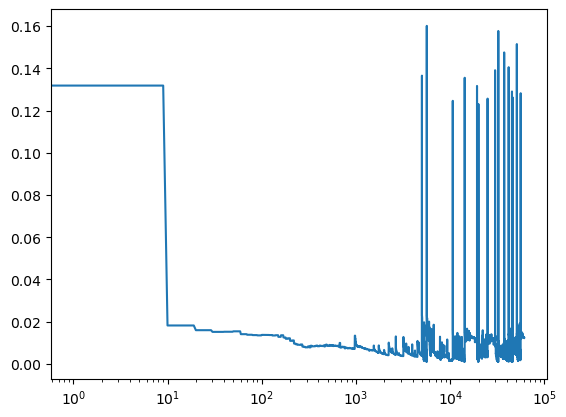

In [11]:
alldf['val_loss'].plot(logx=True)

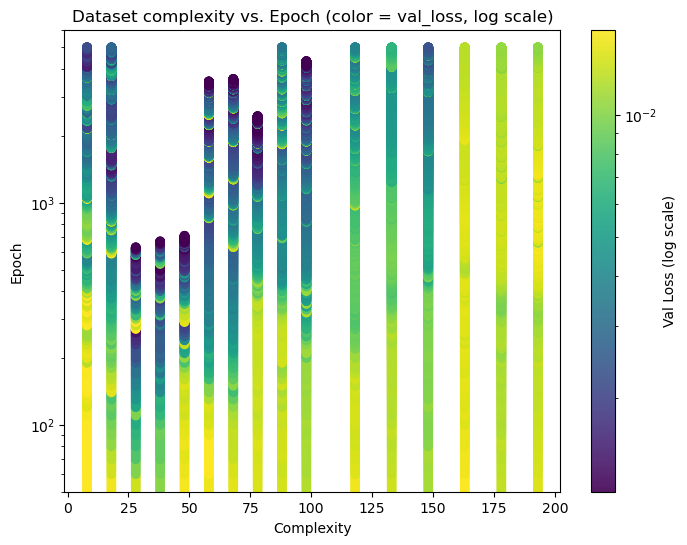

In [36]:

low_q = alldf['val_loss'].quantile(0.01)  # 1° percentile
high_q = alldf['val_loss'].quantile(0.99) # 99° percentile

val_loss_for_color = alldf['val_loss'].clip(lower=low_q, upper=high_q)

# Se qualche val_loss è zero, o vuoi evitare problemi di log(0),
# puoi aggiungere un piccolo offset, tipo df['val_loss'] + 1e-9
#val_loss_for_color = alldf['val_loss'].clip(lower=1e-9)


plt.figure(figsize=(8, 6))
sc = plt.scatter(
    x=alldf['complexity'],
    y=alldf['epoch'],
    c=val_loss_for_color,
    cmap='viridis',
    norm=mcolors.LogNorm(vmin=val_loss_for_color.min(), 
                         vmax=val_loss_for_color.max()),
    alpha=0.9
)

plt.colorbar(sc, label='Val Loss (log scale)')
plt.xlabel('Complexity')
plt.ylabel('Epoch')
plt.ylim(50, 6000)
plt.title('Dataset complexity vs. Epoch (color = val_loss, log scale)')

# Se vuoi mettere in log anche l’asse delle epoche (ma non sempre ha senso):
plt.yscale('log')  

plt.show()


In [15]:
df = alldf

In [16]:
# Supponiamo di avere il tuo DataFrame df con colonne:
#  'complexity', 'epoch', 'val_loss'
# Filtra solo i record validi (niente Nan) se necessario
df = df.dropna(subset=['complexity','epoch','val_loss'])

# 1. Estrarre i valori
x = df['complexity'].values
y = df['epoch'].values

low_q = alldf['val_loss'].quantile(0.01)  # 1° percentile
high_q = alldf['val_loss'].quantile(0.99) # 99° percentile
val_loss_for_color = alldf['val_loss'].clip(lower=low_q, upper=high_q)
z = val_loss_for_color   # df['val_loss'].values

In [37]:
# 2. Creare la griglia
#xi = np.logspace(np.log10(x.min()), np.log10(x.max()), 30, endpoint=True)
#yi = np.logspace(np.log10(y.min()), np.log10(y.max()), 30, endpoint=True)
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 50)
X, Y = np.meshgrid(xi, yi)

# 3. Interpolazione (metodo 'linear' o 'cubic' o 'nearest')
Z = griddata((x, y), z, (X, Y), method='linear')

# Se desideri scala log, e se tutti i z>0

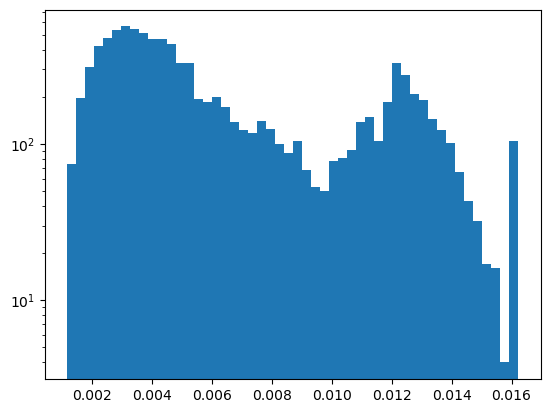

In [18]:
plt.hist(Z.ravel(), bins=50, log=True);

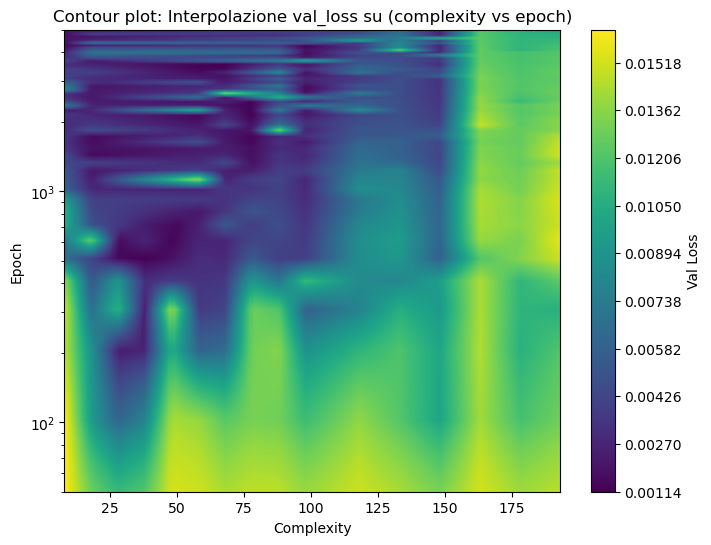

In [38]:
# (altrimenti potresti clipparli, es. np.clip(Z, 1e-9, None))
#norm = mcolors.LogNorm(vmin=np.nanmin(Z), vmax=np.nanmax(Z))
norm = mcolors.LogNorm(vmin=0.001, #val_loss_for_color.min(), 
                         vmax=high_q) #val_loss_for_color.max())

# 4. Plot contourf
plt.figure(figsize=(8, 6))
cs = plt.contourf(X, Y, Z, levels=300, cmap='viridis') # , norm=norm) #se vuoi log
plt.colorbar(cs, label='Val Loss')
plt.xlabel('Complexity')
plt.ylabel('Epoch')
plt.ylim(50, 5000)
plt.yscale('log') 
plt.title('Contour plot: Interpolazione val_loss su (complexity vs epoch)')
plt.show()